# Dacon E-Commerce Dataset - 고객 세그먼테이션
## RFM 분석

---

## 분석 개요

본 분석은 Dacon E-Commerce Dataset을 활용하여 **RFM(Recency, Frequency, Monetary) 분석**을 수행하고, 고객 가치를 정량적으로 평가하여 **5개 멤버십 등급(Bronze / Silver / Gold / Platinum / Diamond)** 으로 세분화한다. 이를 통해 등급별 특성에 맞는 마케팅 전략을 제시한다.

| 항목 | 내용 |
|------|------|
| 데이터 기간 | 2019-01-01 - 2019-12-31 |
| 분석 기준일 | 2019-12-31 |
| 전체 거래 건수 | 25,036건 |
| 전체 고객 수 | 1,468명 |

---

## RFM 분석이란?

RFM 분석은 고객의 구매 행동을 3가지 지표로 평가하는 세그먼테이션 기법으로, 마케팅 전략 수립에 널리 활용된다.

| 지표 | 의미 | 측정 방법 |
|------|------|----------|
| **R** (Recency) | 최근성 | 마지막 구매 후 경과 일수 |
| **F** (Frequency) | 빈도 | 총 고유 거래 수 |
| **M** (Monetary) | 구매 금액 | 총 세후 구매금액 합산 |

세 지표를 종합하면 **"최근에 자주, 많이 구매한 고객일수록 높은 가치를 지닌다"** 는 가정 하에 고객을 정량적으로 평가할 수 있다.

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from dotenv import load_dotenv
import os

load_dotenv()

engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)

In [2]:
with engine.connect() as conn:
    df = pd.read_sql(text('SELECT * FROM orders_master'), conn)

df['거래날짜'] = pd.to_datetime(df['거래날짜'])
df.head()

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,연도,...,할인적용여부,할인후금액,세후금액,성별,고객지역,가입기간,오프라인비용,온라인비용,최종결제금액,거래_총금액
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,2019,...,1,138.34,152.17,남,Chicago,12,4500,2424.5,158.67,158.67
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,2019,...,1,138.34,152.17,남,Chicago,12,4500,2424.5,158.67,158.67
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,2019,...,1,1.84,2.02,남,Chicago,12,4500,2424.5,8.52,8.52
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,2019,...,0,87.65,103.43,남,Chicago,12,4500,2424.5,109.93,833.50
4,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used,2019,...,1,14.85,17.52,남,Chicago,12,4500,2424.5,24.02,833.50


In [3]:
df.shape

(52659, 25)

In [4]:
reference_date = pd.Timestamp('2019-12-31')
print(f'분석 기간: {df["거래날짜"].min().date()} ~ {df["거래날짜"].max().date()}')
print(f'분석 기준일: {reference_date.date()}')
print(f'고객 수: {df["고객ID"].nunique():,}명')
print(f'거래 수: {df["거래ID"].nunique():,}건')

분석 기간: 2019-01-01 ~ 2019-12-31
분석 기준일: 2019-12-31
고객 수: 1,468명
거래 수: 25,036건


---
## RFM 지표 산출

In [5]:
rfm = df.groupby('고객ID').agg(
    Recency=('거래날짜', lambda x: (reference_date - x.max()).days),
    Frequency=('거래ID', 'nunique'),
    Monetary=('세후금액', 'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)
rfm.head()

,고객ID,Recency,Frequency,Monetary
0,USER_0000,107,1,24.98
1,USER_0001,59,31,14997.04
2,USER_0002,73,8,1492.41
3,USER_0003,17,11,1339.57
4,USER_0004,107,13,1369.94


In [6]:
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)

,Recency,Frequency,Monetary
count,1468.00,1468.00,1468.00
mean,144.29,18.12,3285.17
std,101.94,24.94,5262.11
min,0.00,1.00,0.99
25%,55.00,5.00,673.29
50%,131.00,11.00,1796.66
75%,220.00,23.00,4078.90
max,364.00,327.00,80979.02


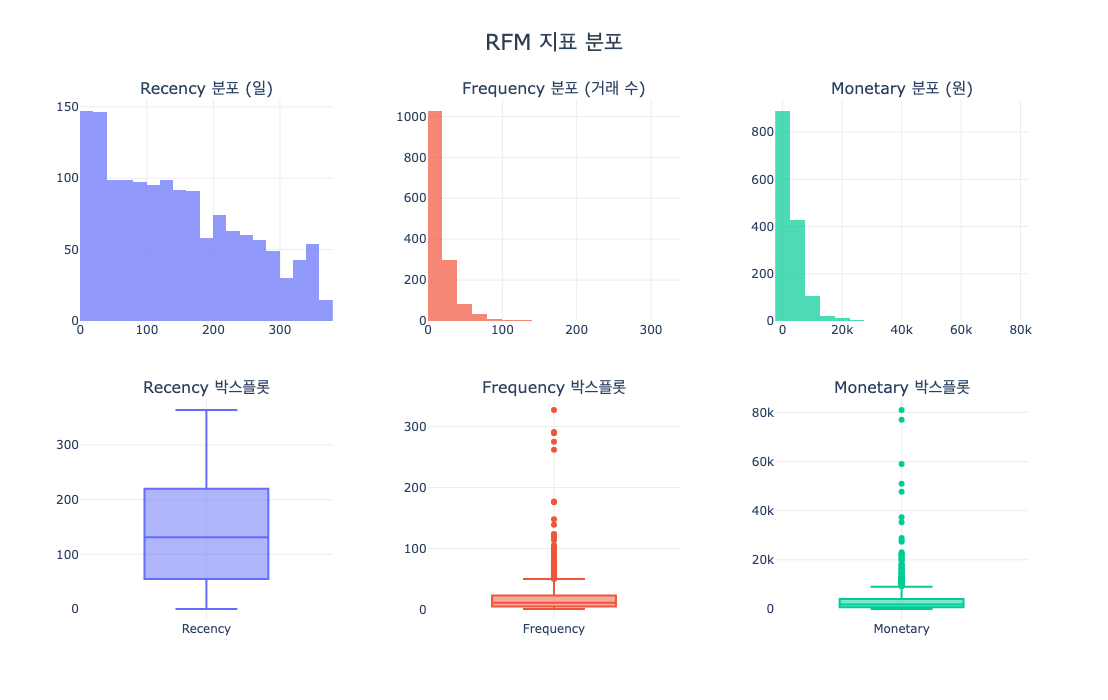

In [7]:
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        'Recency 분포 (일)', 'Frequency 분포 (거래 수)', 'Monetary 분포 (원)',
        'Recency 박스플롯', 'Frequency 박스플롯', 'Monetary 박스플롯'
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

metrics = ['Recency', 'Frequency', 'Monetary']
colors = ['#636EFA', '#EF553B', '#00CC96']

for i, (metric, color) in enumerate(zip(metrics, colors), 1):
    fig.add_trace(
        go.Histogram(x=rfm[metric], marker_color=color, opacity=0.7,
                     name=metric, showlegend=False, nbinsx=30),
        row=1, col=i
    )
    fig.add_trace(
        go.Box(y=rfm[metric], marker_color=color, name=metric,
               showlegend=False, boxpoints='outliers'),
        row=2, col=i
    )

fig.update_layout(
    title=dict(text='RFM 지표 분포',
               font=dict(size=22, color='#2c3e50'), x=0.5, xanchor='center'),
    height=700, plot_bgcolor='white'
)
fig.update_xaxes(gridcolor='#ececec')
fig.update_yaxes(gridcolor='#ececec')
fig.show()

---
## RFM 지표 점수화 (1-5점)

RFM 지표 분포를 확인한 결과, 각 지표의 특성에 맞게 점수화 방식을 다르게 적용했다.

### R (Recency) — Quantile 5등분
분포가 비교적 균등한 형태로, 단순 Quantile 5등분을 적용했다.  
최근 구매일수록 높은 점수를 부여한다 (역순).

### F (Frequency) / M (Monetary) — IQR 기반 5등분
두 지표 모두 오른쪽 긴 꼬리(right-skewed) 분포로 이상치가 존재한다.  
단순 5등분 시 이상치가 일반 고객과 같은 구간에 묶이는 문제가 발생하므로,  
IQR 상한선(`Q3 + 1.5 × IQR`)을 기준으로 이상치를 별도 구간으로 분리한다.

| 점수 | 구간 |
|------|------|
| 1점 | ≤ Q1 |
| 2점 | Q1 - Q2 |
| 3점 | Q2 - Q3 |
| 4점 | Q3 - Q3 + 1.5×IQR |
| 5점 | Q3 + 1.5×IQR 초과 (이상치 구간) |

In [8]:
rfm['R'] = pd.qcut(
    rfm['Recency'],
    q=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[5, 4, 3, 2, 1]
).astype(int)

for col in ['Frequency', 'Monetary']:
    q1 = rfm[col].quantile(0.25)
    q2 = rfm[col].quantile(0.50)
    q3 = rfm[col].quantile(0.75)
    upper = q3 + 1.5 * (q3 - q1)
    rfm[col[0]] = pd.cut(
        rfm[col],
        bins=[-np.inf, q1, q2, q3, upper, np.inf],
        labels=[1, 2, 3, 4, 5]
    ).astype(int)

rfm[['R', 'F', 'M']].describe().round(1)

,R,F,M
count,1468.0,1468.0,1468.0
mean,3.0,2.5,2.6
std,1.4,1.2,1.2
min,1.0,1.0,1.0
25%,2.0,1.0,1.8
50%,3.0,2.0,2.5
75%,4.0,3.0,3.2
max,5.0,5.0,5.0


In [9]:
rfm.head()

,고객ID,Recency,Frequency,Monetary,R,F,M
0,USER_0000,107,1,24.98,3,1,1
1,USER_0001,59,31,14997.04,4,4,5
2,USER_0002,73,8,1492.41,4,2,2
3,USER_0003,17,11,1339.57,5,2,2
4,USER_0004,107,13,1369.94,3,3,2


---
## 최적 클러스터 수 결정

KMeans 클러스터링을 수행하기 전, 최적의 클러스터 수(k)를 결정하기 위해 **Elbow Method**와 **Silhouette Score** 두 가지 방법을 함께 사용했다.  
이상치에 민감한 Recency, Frequency, Monetary 원본 수치를 그대로 사용하면 클러스터링 결과가 왜곡될 수 있기 때문에, 이상치에 덜 민감한 **RobustScaler**로 스케일링한 값을 사용했다.

- **Elbow Method**: k가 증가할수록 클러스터 내 분산(Inertia)이 감소하는데, 감소폭이 급격히 줄어드는 지점(꺾이는 지점)을 최적 k로 선택한다.
- **Silhouette Score**: 클러스터링의 품질을 평가하는 지표로, 1에 가까울수록 클러스터가 잘 나뉜 것을 의미한다.

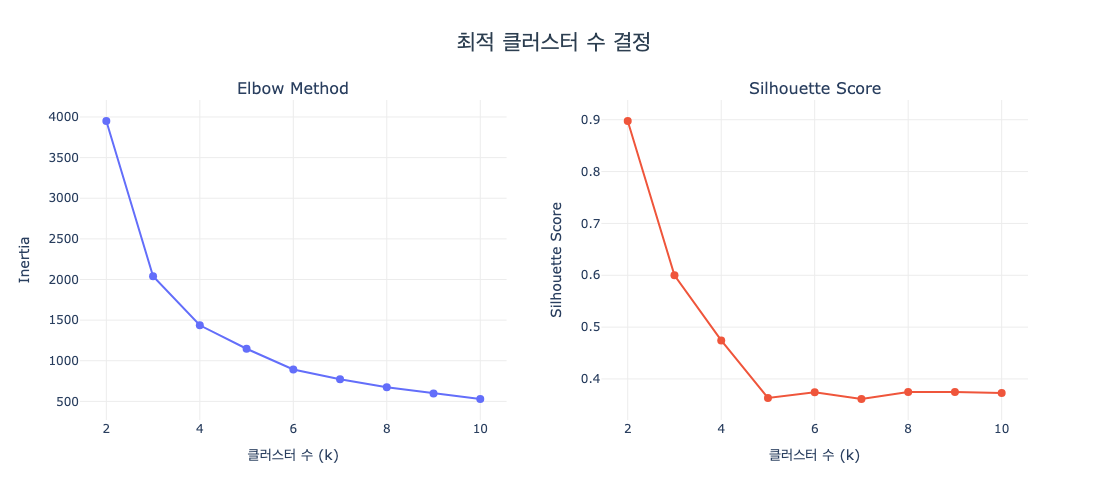

k=2: 0.8976
k=3: 0.5998
k=4: 0.4744
k=5: 0.3634
k=6: 0.3743
k=7: 0.3613
k=8: 0.3747
k=9: 0.3750
k=10: 0.3730


In [10]:
features = rfm[['Recency', 'Frequency', 'Monetary']]
scaler = RobustScaler()
scaled_features = pd.DataFrame(
    scaler.fit_transform(features),
    columns=['Recency', 'Frequency', 'Monetary']
)

inertias, silhouette_scores_list = [], []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    inertias.append(kmeans.inertia_)
    silhouette_scores_list.append(silhouette_score(scaled_features, labels))

fig = make_subplots(rows=1, cols=2, subplot_titles=('Elbow Method', 'Silhouette Score'))

fig.add_trace(
    go.Scatter(x=list(k_range), y=inertias, mode='lines+markers',
               marker=dict(size=8, color='#636EFA'), line=dict(color='#636EFA'),
               showlegend=False),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=list(k_range), y=silhouette_scores_list, mode='lines+markers',
               marker=dict(size=8, color='#EF553B'), line=dict(color='#EF553B'),
               showlegend=False),
    row=1, col=2
)

fig.update_layout(
    title=dict(text='최적 클러스터 수 결정',
               font=dict(size=22, color='#2c3e50'), x=0.5, xanchor='center'),
    height=500, plot_bgcolor='white'
)
fig.update_xaxes(title_text='클러스터 수 (k)', gridcolor='#ececec')
fig.update_yaxes(gridcolor='#ececec')
fig.update_yaxes(title_text='Inertia', row=1, col=1)
fig.update_yaxes(title_text='Silhouette Score', row=1, col=2)
fig.show()

for k, s in zip(k_range, silhouette_scores_list):
    print(f'k={k}: {s:.4f}')

**Silhouette Score**
- k=2에서 최고점(0.898)을 기록하지만, 2개 클러스터는 고객 구조를 충분히 세분화하기 어렵다.
- k=4 이후 0.36-0.37 수준에서 수렴 — 클러스터를 더 늘려도 개선이 없다.

**Elbow Method**
- Inertia 감소폭이 k=4-5 구간에서 완만해진다.

→ 두 방법을 종합하여 **k=4**를 선택한다.

> 이후 PCA 가중치를 적용한 RFM Score 기반으로 등급을 배정하므로, 클러스터 수와 등급 수는 별도로 결정된다.

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(scaled_features)

cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print(cluster_summary)
print('\n클러스터별 고객 수:')
print(rfm['Cluster'].value_counts())

         Recency  Frequency  Monetary
Cluster                              
0          75.70      75.03  14991.34
1         160.15       7.88   1245.26
2         116.00      31.11   5714.78
3          29.20     288.80  63158.45

클러스터별 고객 수:
Cluster
1    1020
2     367
0      76
3       5
Name: count, dtype: int64


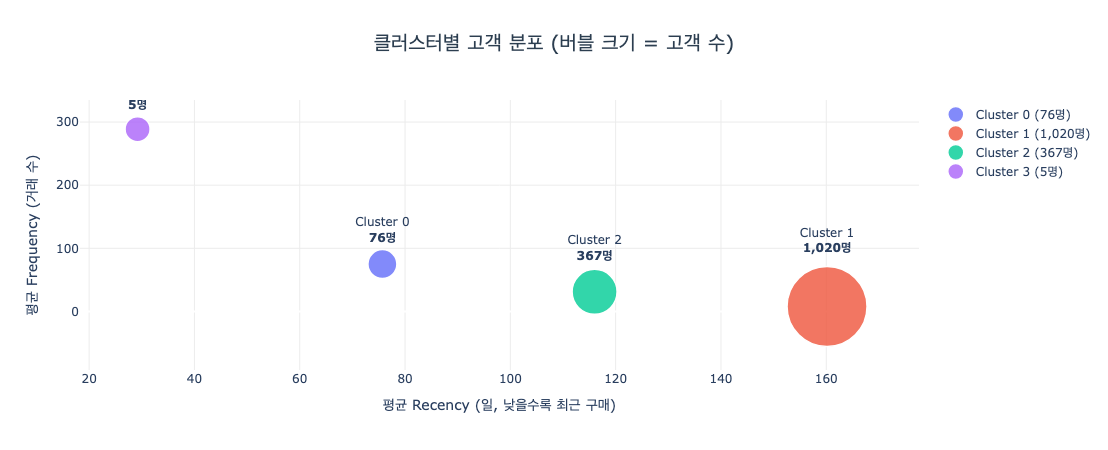

In [12]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()
cluster_viz = rfm.groupby('Cluster')[['Recency', 'Frequency']].mean().round(2)
cluster_viz['Count'] = cluster_counts

colors_bubble = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A']

min_c, max_c = cluster_viz['Count'].min(), cluster_viz['Count'].max()
cluster_viz['Size'] = ((cluster_viz['Count'] - min_c) / (max_c - min_c) * 55 + 25).round(0)

fig = go.Figure()
for cluster_id in sorted(cluster_viz.index):
    row = cluster_viz.loc[cluster_id]
    fig.add_trace(go.Scatter(
        x=[row['Recency']], y=[row['Frequency']],
        mode='markers+text',
        marker=dict(size=row['Size'], color=colors_bubble[cluster_id],
                    opacity=0.8, line=dict(width=1.5, color='white')),
        text=[f'Cluster {cluster_id}<br><b>{int(row["Count"]):,}명</b>'],
        textposition='top center',
        name=f'Cluster {cluster_id} ({int(row["Count"]):,}명)',
        hovertemplate=(
            f'Cluster {cluster_id}<br>'
            'Recency: %{x:.1f}일<br>'
            'Frequency: %{y:.1f}건<extra></extra>'
        )
    ))

fig.update_layout(
    title=dict(text='클러스터별 고객 분포 (버블 크기 = 고객 수)',
               font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'),
    xaxis=dict(title='평균 Recency (일, 낮을수록 최근 구매)', gridcolor='#ececec'),
    yaxis=dict(title='평균 Frequency (거래 수)', gridcolor='#ececec'),
    plot_bgcolor='white', width=800, height=450, showlegend=True
)
fig.show()

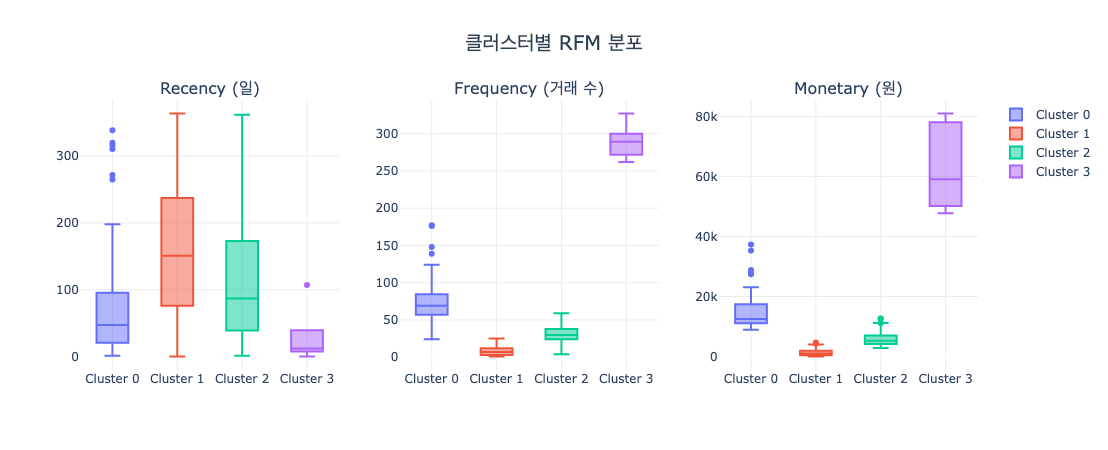

In [13]:
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=['Recency (일)', 'Frequency (거래 수)', 'Monetary (원)'])

for i, metric in enumerate(['Recency', 'Frequency', 'Monetary'], 1):
    for j, cluster_id in enumerate(sorted(rfm['Cluster'].unique())):
        data = rfm[rfm['Cluster'] == cluster_id][metric]
        fig.add_trace(go.Box(
            y=data, name=f'Cluster {cluster_id}',
            marker_color=colors_bubble[j], boxpoints='outliers',
            showlegend=(i == 1)  # 범례 중복 방지
        ), row=1, col=i)

fig.update_layout(
    title=dict(text='클러스터별 RFM 분포',
               font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'),
    width=1200, height=450, plot_bgcolor='white'
)
fig.update_xaxes(gridcolor='#ececec')
fig.update_yaxes(gridcolor='#ececec')
fig.show()

### 클러스터 결과 해석

클러스터별 Recency(최근성)와 Frequency(구매 빈도) 분포를 확인한 결과, 아래와 같이 4개 그룹으로 분리됐다.

| 클러스터 | 평균 Recency | 평균 Frequency | 평균 Monetary | 고객 수 | 특징 |
|---------|------------|--------------|-------------|--------|-----|
| Cluster 3 | 29.2일 | 288.8건 | 63,158원 | 5명 | 극단적 헤비유저 |
| Cluster 0 | 75.7일 | 75.0건 | 14,991원 | 76명 | 고활성 고가치 |
| Cluster 2 | 116.0일 | 31.1건 | 5,715원 | 367명 | 중간 활성 |
| Cluster 1 | 160.2일 | 7.9건 | 1,245원 | 1,020명 | 저활성 저가치 |

Cluster 3의 고객 수(5명)가 극단적으로 적은 것은 문제가 아니라, KMeans가 극단적 이상치 고객을 나머지 그룹과 자연스럽게 분리한 결과다. Frequency IQR 기반 스코어링에서 5점을 받은 고객층이 별도 클러스터로 묶인 것과 같은 맥락이다.

**KMeans의 한계 → PCA로 보완**
- KMeans는 클러스터 간 **상대적 위치**만 반영할 뿐, R / F / M이 단일 점수로 통합될 때의 **상대적 중요도**는 알 수 없다.
- **PCA(주성분 분석)** 로 R / F / M의 분산 기여도를 기반으로 가중치를 데이터 기반으로 도출한다.
- 클러스터 레이블 없이 데이터 구조 자체에서 가중치를 추출하므로 순환 의존성 없이 객관적인 가중치 산출이 가능하다.

---
## 가중치 설정하기

R / F / M 세 지표를 하나의 점수로 합산할 때 가장 간단한 방법은 **동일 가중치(1/3씩)** 를 부여하는 것이다.  
그러나 동일 가중치는 세 지표가 고객 구분에 동등하게 기여한다는 가정을 전제로 하며, 실제 데이터의 분포 차이를 무시한다.

반대로 **수작업으로 가중치를 조정**하면 분석가의 직관이나 도메인 지식에 의존하게 되어 주관성이 개입된다.

**PCA(주성분 분석)** 는 이 문제를 데이터 기반으로 해결한다.  
R / F / M 점수(1-5)에 PCA를 적용하면, 첫 번째 주성분(PC1)이 세 지표의 **분산을 가장 많이 설명하는 방향**을 찾아낸다.  
각 지표의 PC1 로딩값은 해당 지표가 고객 간 차이를 설명하는 데 얼마나 기여하는지를 나타내며, 이를 절댓값 정규화하여 가중치로 사용한다.

즉, 데이터 안에서 고객 차이를 가장 잘 설명하는 방향을 자동으로 찾아 가중치를 결정하므로, 임의 설정 없이 데이터 구조를 반영한 객관적인 가중치 산출이 가능하다.

### 공식

```
RFM Score = (R × w_r + F × w_f + M × w_m) / 5 × 100  →  20-100점
```

> R / F / M이 모두 1-5점 범위로 산출되므로, 최솟값은 20점(세 지표 모두 1점), 최댓값은 100점(세 지표 모두 5점)이 된다.

In [14]:
X_rfm = rfm[['R', 'F', 'M']]
scaler_pca = RobustScaler()
X_scaled_pca = scaler_pca.fit_transform(X_rfm)

pca = PCA(n_components=1)
pca.fit(X_scaled_pca)

loadings = np.abs(pca.components_[0])
weights = loadings / loadings.sum()
r_w, f_w, m_w = weights

print(f'R 가중치: {r_w:.4f}')
print(f'F 가중치: {f_w:.4f}')
print(f'M 가중치: {m_w:.4f}')
print(f'합계: {r_w + f_w + m_w:.4f}')
print(f'PC1 설명 분산 비율: {pca.explained_variance_ratio_[0]:.3f}')

R 가중치: 0.2011
F 가중치: 0.3389
M 가중치: 0.4600
합계: 1.0000
PC1 설명 분산 비율: 0.694


In [15]:
rfm['RFM_score'] = (
    rfm['R'] * r_w +
    rfm['F'] * f_w +
    rfm['M'] * m_w
) / 5 * 100

In [16]:
print(rfm['RFM_score'].describe(percentiles=[.10, .20, .30, .40, .50, .60, .70, .80, .90, .96]))

count    1468.000000
mean       52.699754
std        21.670368
min        20.000000
10%        24.021684
20%        30.800311
30%        36.086737
40%        44.021684
50%        51.956632
60%        58.843679
70%        66.778626
80%        71.956632
90%        84.021684
96%        93.221374
max       100.000000
Name: RFM_score, dtype: float64


**등급 기준 설정 근거**

RFM 점수(20-100)의 백분위 분포를 기반으로, 상위로 갈수록 인원이 줄어드는 피라미드 구조를 의도하여 컷오프를 설정했다.

| 등급 | 기준 | 백분위 근거 |
|------|------|------------|
| Diamond | ≥ 95 | 상위 약 4% — 최상위 소수 집중 |
| Platinum | ≥ 80 | 상위 약 14% — 80th-90th percentile 구간 |
| Gold | ≥ 65 | 상위 약 31% — 70th percentile(66.8) 기준 |
| Silver | ≥ 50 | 상위 약 52% — 중앙값(51.96) 기준으로 상위/하위 분리 |
| Bronze | < 50 | 하위 약 48% — 재참여 대상 |

In [17]:
def assign_grade(score):
    if score >= 95:
        return 'Diamond'
    elif score >= 80:
        return 'Platinum'
    elif score >= 65:
        return 'Gold'
    elif score >= 50:
        return 'Silver'
    else:
        return 'Bronze'

rfm['등급'] = rfm['RFM_score'].apply(assign_grade)
rfm['등급'].value_counts()

등급
Bronze      699
Silver      314
Gold        243
Platinum    154
Diamond      58
Name: count, dtype: int64

---
## RFM 세그먼트 배정

RFM 세그먼테이션 참고자료를 바탕으로 R / F / M 점수 조합으로 각 고객에게 행동 기반 세그먼트 라벨을 부여한다.  
등급(Grade)이 고객 가치의 **수준**을 나타낸다면, 세그먼트는 고객의 현재 **상태**를 나타낸다.
>참고 자료 링크: https://documentation.bloomreach.com/engagement/docs/rfm-segmentation

| 세그먼트 | 원문 | 특징 | 점수 조합 |
|---------|------|------|----------|
| VIP 고객 | Champions | 최근에 자주, 많이 구매한 핵심 고객 | 555, 554, 544, 545, 454, 455, 445 |
| 충성 고객 | Loyal | 지속적으로 구매하는 충성 고객 | 543, 444, 435, 355, 354, 345, 344, 335 |
| 잠재 충성 고객 | Potential Loyalist | 최근 구매했고 충성 고객이 될 가능성이 높은 고객 | 553, 551, 552, 541, 542, 533, 532, 531, 452, 451, 442, 441, 431, 453, 433, 432, 423, 353, 352, 351, 342, 341, 333, 323 |
| 신규 고객 | New Customers | 최근에 처음 구매한 신규 유입 고객 | 512, 511, 422, 421, 412, 411, 311 |
| 가망 고객 | Promising | 최근 구매했지만 빈도·금액이 아직 낮은 고객 | 525, 524, 523, 522, 521, 515, 514, 513, 425, 424, 413, 414, 415, 315, 314, 313 |
| 관심 필요 고객 | Need Attention | 평균 수준이나 최근성이 떨어지기 시작한 고객 | 535, 534, 443, 434, 343, 334, 325, 324 |
| 이탈 조짐 고객 | About to Sleep | 구매 간격이 벌어지고 있는 이탈 위험 고객 | 331, 321, 312, 221, 213, 231, 241, 251 |
| 놓치면 안될 고객 | Cannot Lose Them | 과거 고가치였지만 오랫동안 구매하지 않은 고객 | 155, 154, 144, 214, 215, 115, 114, 113 |
| 이탈 위험 고객 | At Risk | 예전에 자주 샀지만 최근 방문이 없는 고객 | 255, 254, 245, 244, 253, 252, 243, 242, 235, 234, 225, 224, 153, 152, 145, 143, 142, 135, 134, 133, 125, 124 |
| 휴면 고객 | Hibernating | 오랫동안 비활성 상태인 고객 | 332, 322, 233, 232, 223, 222, 132, 123, 122, 212, 211 |
| 이탈 고객 | Lost | 완전히 이탈한 것으로 보이는 고객 | 111, 112, 121, 131, 141, 151 |

In [18]:
segment_rules = {
    'VIP 고객': {
        '555','554','544','545','454','455','445'
    },
    '충성 고객': {
        '543','444','435','355','354','345','344','335'
    },
    '잠재 충성 고객': {
        '553','551','552','541','542','533','532','531',
        '452','451','442','441','431','453','433','432',
        '423','353','352','351','342','341','333','323'
    },
    '신규 고객': {
        '512','511','422','421','412','411','311'
    },
    '가망 고객': {
        '525','524','523','522','521','515','514','513',
        '425','424','413','414','415','315','314','313'
    },
    '관심 필요 고객': {
        '535','534','443','434','343','334','325','324'
    },
    '이탈 조짐 고객': {
        '331','321','312','221','213','231','241','251'
    },
    '놓치면 안될 고객': {
        '155','154','144','214','215','115','114','113'
    },
    '이탈 위험 고객': {
        '255','254','245','244','253','252','243','242',
        '235','234','225','224','153','152','145','143',
        '142','135','134','133','125','124'
    },
    '휴면 고객': {
        '332','322','233','232','223','222','132','123','122','212','211'
    },
    '이탈 고객': {
        '111','112','121','131','141','151'
    },
}

score_to_segment = {
    code: seg
    for seg, codes in segment_rules.items()
    for code in codes
}

rfm['Segment'] = rfm.apply(
    lambda row: score_to_segment.get(f"{row['R']}{row['F']}{row['M']}", 'Others'),
    axis=1
)
rfm['Segment'].value_counts()

Segment
휴면 고객        356
신규 고객        220
잠재 충성 고객     205
VIP 고객       135
이탈 고객        129
충성 고객        116
이탈 위험 고객     102
가망 고객         63
관심 필요 고객      51
이탈 조짐 고객      47
놓치면 안될 고객     44
Name: count, dtype: int64

In [19]:
seg_dist = (
    rfm['Segment'].value_counts()
    .reset_index()
    .rename(columns={'Segment': '세그먼트', 'count': '고객수'})
)
seg_dist

,세그먼트,고객수
0,휴면 고객,356
1,신규 고객,220
2,잠재 충성 고객,205
3,VIP 고객,135
4,이탈 고객,129
5,충성 고객,116
6,이탈 위험 고객,102
7,가망 고객,63
8,관심 필요 고객,51
9,이탈 조짐 고객,47


11개 세그먼트 규칙은 R/F/M 점수 조합 가능한 125가지(5×5×5) 경우를 모두 커버하므로, Others에 해당하는 고객은 **0명(0%)** 이다.

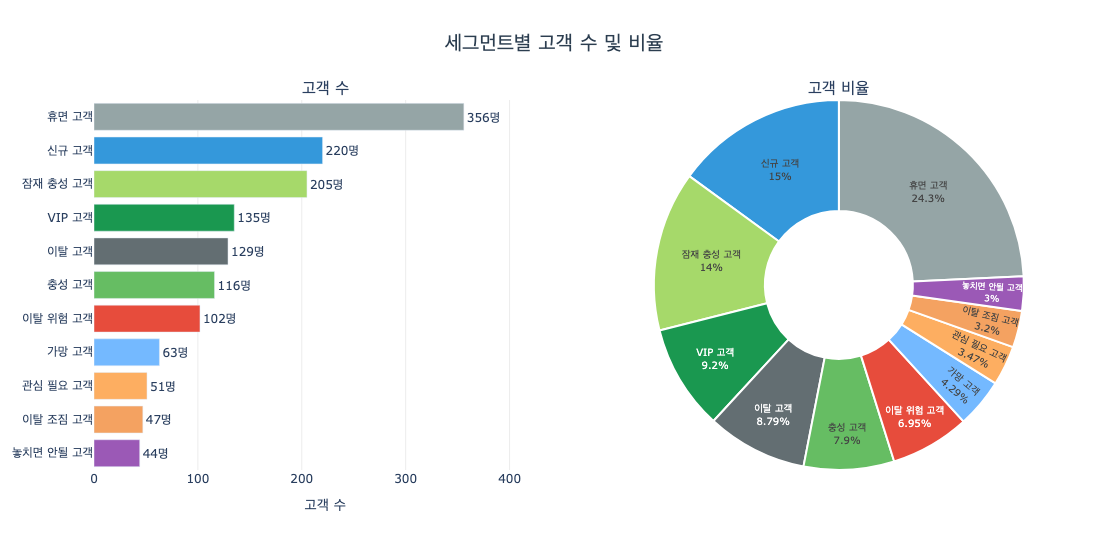

In [20]:
seg_color_map = {
    'VIP 고객': '#1a9850',
    '충성 고객': '#66bd63',
    '잠재 충성 고객': '#a6d96a',
    '신규 고객': '#3498db',
    '가망 고객': '#74b9ff',
    '관심 필요 고객': '#fdae61',
    '이탈 조짐 고객': '#f4a261',
    '놓치면 안될 고객': '#9b59b6',
    '이탈 위험 고객': '#e74c3c',
    '휴면 고객': '#95a5a6',
    '이탈 고객': '#636e72',
    'Others': '#dfe6e9',
}

seg_sorted = seg_dist.sort_values('고객수', ascending=True)
seg_colors_sorted = [seg_color_map.get(s, '#dfe6e9') for s in seg_sorted['세그먼트']]

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'xy'}, {'type': 'pie'}]],
    column_widths=[0.55, 0.45],
    subplot_titles=['고객 수', '고객 비율']
)

fig.add_trace(
    go.Bar(
        x=seg_sorted['고객수'],
        y=seg_sorted['세그먼트'],
        orientation='h',
        marker_color=seg_colors_sorted,
        text=seg_sorted['고객수'].apply(lambda x: f'{x:,}명'),
        textposition='outside',
        showlegend=False
    ),
    row=1, col=1
)

fig.add_trace(
    go.Pie(
        labels=seg_dist['세그먼트'],
        values=seg_dist['고객수'],
        marker=dict(
            colors=[seg_color_map.get(s, '#dfe6e9') for s in seg_dist['세그먼트']],
            line=dict(color='white', width=2)
        ),
        textinfo='label+percent',
        textposition='inside',
        textfont=dict(size=10),
        hole=0.4,
        sort=False,
        showlegend=False
    ),
    row=1, col=2
)

fig.update_layout(
    title=dict(
        text='세그먼트별 고객 수 및 비율',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    xaxis=dict(range=[0, seg_sorted['고객수'].max() * 1.25], gridcolor='#ececec', title='고객 수'),
    plot_bgcolor='white',
    height=550
)
fig.show()

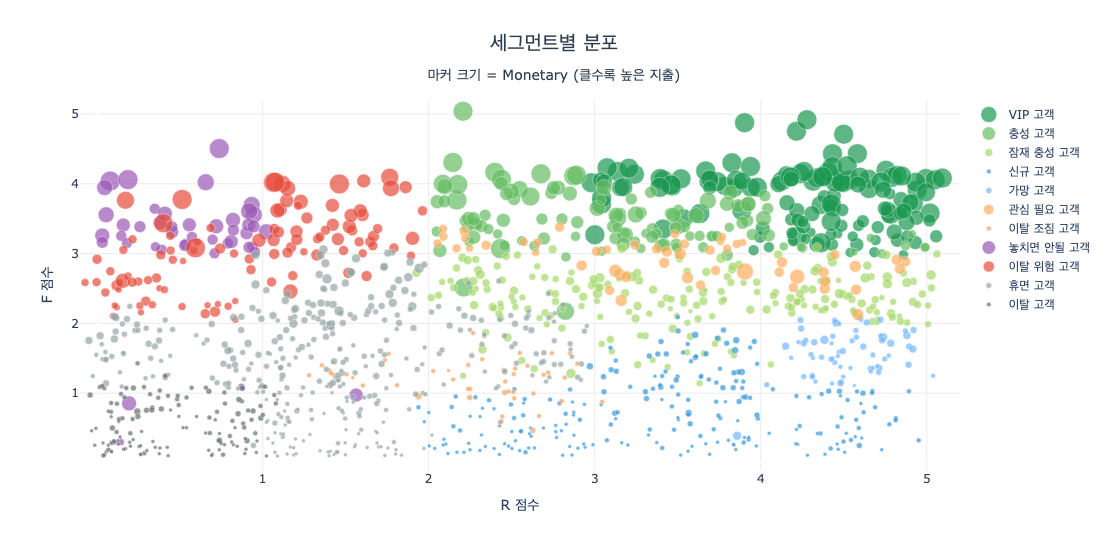

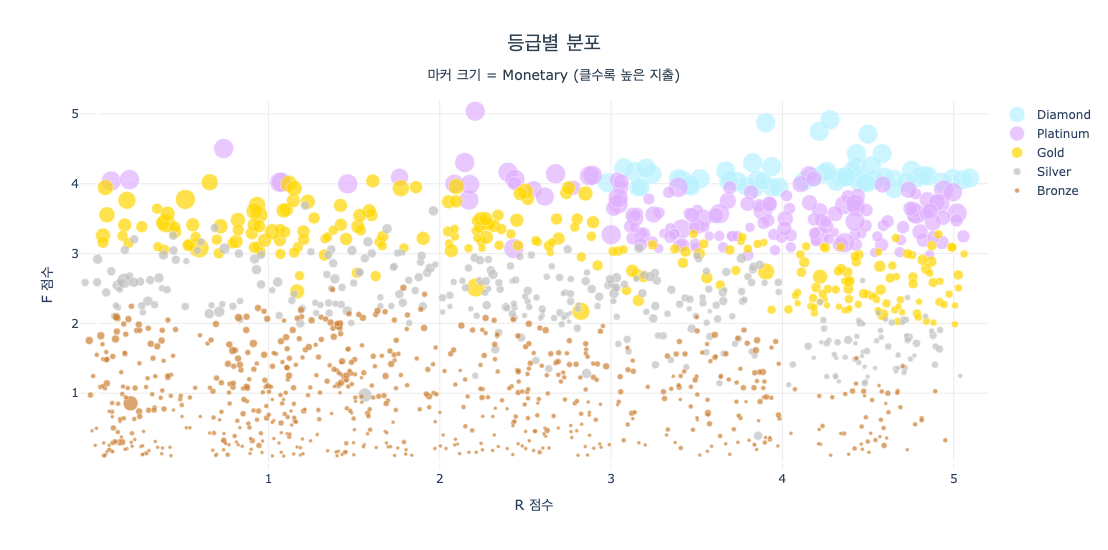

In [21]:
rfm_plot = rfm.copy()

# Bin-interpolation scaling (RFM_scale 패턴)
r_intervals = pd.qcut(rfm_plot['Recency'], q=[0, 0.2, 0.4, 0.6, 0.8, 1.0])
r_left = r_intervals.apply(lambda x: x.left).astype(float).clip(lower=0)
r_right = r_intervals.apply(lambda x: x.right).astype(float)
rfm_plot['R_scale'] = (rfm_plot['R'] - 1) + (rfm_plot['Recency'] - r_left - 0.01) / (r_right - r_left) - 0.0001

f_q1 = rfm_plot['Frequency'].quantile(0.25)
f_q2 = rfm_plot['Frequency'].quantile(0.50)
f_q3 = rfm_plot['Frequency'].quantile(0.75)
f_upper = f_q3 + 1.5 * (f_q3 - f_q1)
f_intervals = pd.cut(rfm_plot['Frequency'], bins=[0, f_q1, f_q2, f_q3, f_upper, rfm_plot['Frequency'].max()])
f_left = f_intervals.apply(lambda x: x.left).astype(float)
f_right = f_intervals.apply(lambda x: x.right).astype(float)
rfm_plot['F_scale'] = (rfm_plot['F'] - 1) + (rfm_plot['Frequency'] - f_left - 0.01) / (f_right - f_left) - 0.0001

np.random.seed(42)
rfm_plot['R_scale'] += np.random.uniform(-0.1, 0.1, len(rfm_plot))
rfm_plot['F_scale'] += np.random.uniform(-0.1, 0.1, len(rfm_plot))

m_min = rfm_plot['Monetary'].min()
m_cap = rfm_plot['Monetary'].quantile(0.95)
rfm_plot['marker_size'] = (
    (rfm_plot['Monetary'].clip(upper=m_cap) - m_min) / (m_cap - m_min) * 16 + 4
).round(0)

segment_colors = {
    'VIP 고객': '#1a9850',
    '충성 고객': '#66bd63',
    '잠재 충성 고객': '#a6d96a',
    '신규 고객': '#3498db',
    '가망 고객': '#74b9ff',
    '관심 필요 고객': '#fdae61',
    '이탈 조짐 고객': '#f4a261',
    '놓치면 안될 고객': '#9b59b6',
    '이탈 위험 고객': '#e74c3c',
    '휴면 고객': '#95a5a6',
    '이탈 고객': '#636e72',
    'Others': '#dfe6e9',
}
grade_color_map = {
    'Diamond': '#B9F2FF',
    'Platinum': '#E0B0FF',
    'Gold': '#FFD700',
    'Silver': '#C0C0C0',
    'Bronze': '#CD7F32',
}

# 세그먼트별 분포
fig1 = go.Figure()
for segment, color in segment_colors.items():
    sub = rfm_plot[rfm_plot['Segment'] == segment]
    if len(sub) == 0:
        continue
    fig1.add_trace(go.Scatter(
        x=sub['R_scale'],
        y=sub['F_scale'],
        mode='markers',
        marker=dict(color=color, size=sub['marker_size'], opacity=0.7,
                    line=dict(width=0.5, color='white')),
        name=segment,
        hovertemplate=(
            '등급: %{customdata[0]}<br>'
            f'세그먼트: {segment}<br>'
            'R: %{customdata[1]} | F: %{customdata[2]}<br>'
            'Monetary: %{customdata[3]:,.0f}원<extra></extra>'
        ),
        customdata=sub[['등급', 'R', 'F', 'Monetary']].values
    ))

fig1.update_layout(
    title=dict(
        text='세그먼트별 분포<br><sub>마커 크기 = Monetary (클수록 높은 지출)</sub>',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    xaxis=dict(tickvals=[1, 2, 3, 4, 5], range=[-0.1, 5.2], gridcolor='#ececec', title_text='R 점수'),
    yaxis=dict(tickvals=[1, 2, 3, 4, 5], range=[-0.1, 5.2], gridcolor='#ececec', title_text='F 점수'),
    plot_bgcolor='white',
    width=700,
    height=550,
    legend=dict(orientation='v', x=1.01, y=1)
)
fig1.show()

# 등급별 분포
fig2 = go.Figure()
for grade in ['Diamond', 'Platinum', 'Gold', 'Silver', 'Bronze']:
    sub = rfm_plot[rfm_plot['등급'] == grade]
    fig2.add_trace(go.Scatter(
        x=sub['R_scale'],
        y=sub['F_scale'],
        mode='markers',
        marker=dict(color=grade_color_map[grade], size=sub['marker_size'], opacity=0.7,
                    line=dict(width=0.5, color='white')),
        name=grade,
        hovertemplate=(
            f'등급: {grade}<br>'
            'R: %{customdata[0]} | F: %{customdata[1]}<br>'
            'Monetary: %{customdata[2]:,.0f}원<extra></extra>'
        ),
        customdata=sub[['R', 'F', 'Monetary']].values
    ))

fig2.update_layout(
    title=dict(
        text='등급별 분포<br><sub>마커 크기 = Monetary (클수록 높은 지출)</sub>',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    xaxis=dict(tickvals=[1, 2, 3, 4, 5], range=[-0.1, 5.2], gridcolor='#ececec', title_text='R 점수'),
    yaxis=dict(tickvals=[1, 2, 3, 4, 5], range=[-0.1, 5.2], gridcolor='#ececec', title_text='F 점수'),
    plot_bgcolor='white',
    width=700,
    height=550,
    legend=dict(orientation='v', x=1.01, y=1)
)
fig2.show()

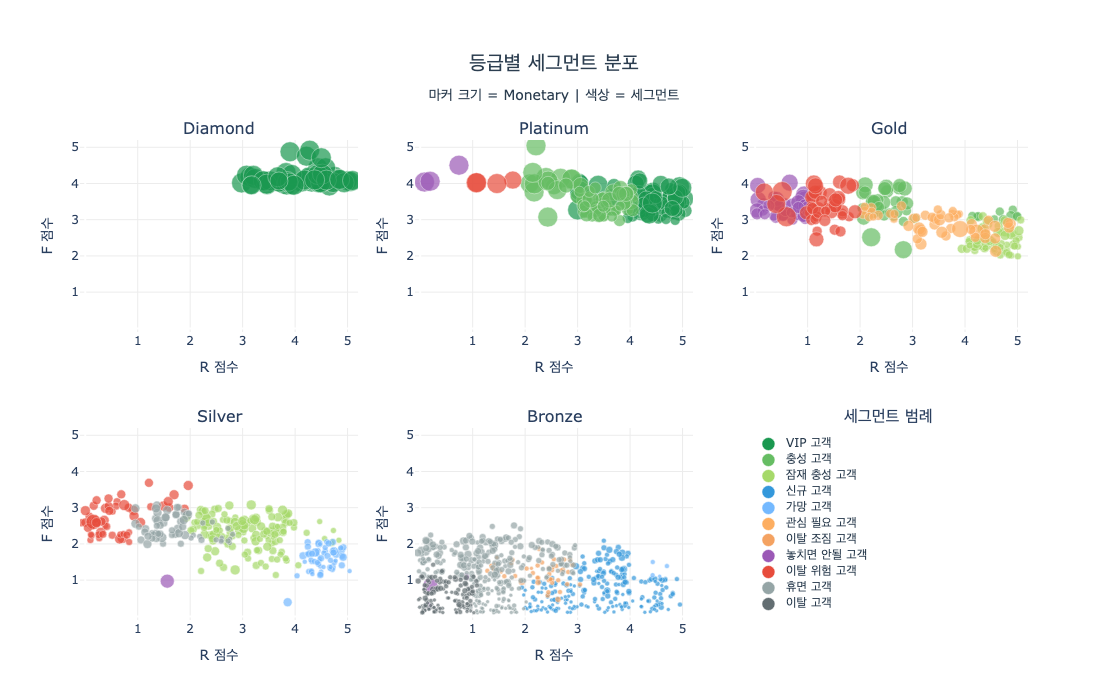

In [22]:
grade_order_seg = ['Diamond', 'Platinum', 'Gold', 'Silver', 'Bronze']

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=grade_order_seg + ['세그먼트 범례'],
    shared_yaxes=False,
    vertical_spacing=0.2,
    horizontal_spacing=0.06
)

positions = [(1,1),(1,2),(1,3),(2,1),(2,2)]
for (row, col), grade in zip(positions, grade_order_seg):
    sub_grade = rfm_plot[rfm_plot['등급'] == grade]
    for segment, color in segment_colors.items():
        sub = sub_grade[sub_grade['Segment'] == segment]
        if len(sub) == 0:
            continue
        fig.add_trace(go.Scatter(
            x=sub['R_scale'],
            y=sub['F_scale'],
            mode='markers',
            marker=dict(
                color=color,
                size=sub['marker_size'],
                opacity=0.7,
                line=dict(width=0.5, color='white')
            ),
            name=segment,
            showlegend=False,
            hovertemplate=(
                f'등급: {grade}<br>'
                f'세그먼트: {segment}<br>'
                'R: %{customdata[0]} | F: %{customdata[1]}<br>'
                'Monetary: %{customdata[2]:,.0f}원<extra></extra>'
            ),
            customdata=sub[['R', 'F', 'Monetary']].values
        ), row=row, col=col)

legend_items = [(seg, color) for seg, color in segment_colors.items() if seg != 'Others']
total = len(legend_items)
for i, (segment, color) in enumerate(legend_items):
    fig.add_trace(go.Scatter(
        x=[0.1],
        y=[total - i],
        mode='markers+text',
        marker=dict(color=color, size=13, line=dict(width=0.5, color='white')),
        text=[f'  {segment}'],
        textposition='middle right',
        textfont=dict(size=12, color='#2c3e50'),
        showlegend=False,
        hoverinfo='skip'
    ), row=2, col=3)

for row, col in positions:
    fig.update_xaxes(tickvals=[1,2,3,4,5], range=[-0.1, 5.2], gridcolor='#ececec', title_text='R 점수', row=row, col=col)
    fig.update_yaxes(tickvals=[1,2,3,4,5], range=[-0.1, 5.2], gridcolor='#ececec', title_text='F 점수', row=row, col=col)

fig.update_xaxes(range=[0, 1.5], visible=False, row=2, col=3)
fig.update_yaxes(range=[0, total + 1], visible=False, row=2, col=3)

fig.update_layout(
    title=dict(
        text='등급별 세그먼트 분포<br><sub>마커 크기 = Monetary | 색상 = 세그먼트</sub>',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    plot_bgcolor='white',
    height=700,
    margin=dict(t=140),
    showlegend=False
)
fig.show()

In [23]:
_grade_order = ['Bronze', 'Silver', 'Gold', 'Platinum', 'Diamond']

cross = pd.crosstab(rfm['Segment'], rfm['등급'])
cross = cross.reindex(columns=_grade_order)
cross_pct = (cross.div(cross.sum(axis=0), axis=1) * 100).round(1)
cross_pct

등급,Bronze,Silver,Gold,Platinum,Diamond
Segment,,,,,
VIP 고객,0.0,0.0,0.0,50.0,100.0
가망 고객,0.6,18.8,0.0,0.0,0.0
관심 필요 고객,0.0,0.0,21.0,0.0,0.0
놓치면 안될 고객,0.4,0.3,15.2,1.9,0.0
신규 고객,31.5,0.0,0.0,0.0,0.0
이탈 고객,18.5,0.0,0.0,0.0,0.0
이탈 위험 고객,0.0,17.2,18.1,2.6,0.0
이탈 조짐 고객,6.7,0.0,0.0,0.0,0.0
잠재 충성 고객,0.0,44.6,26.7,0.0,0.0


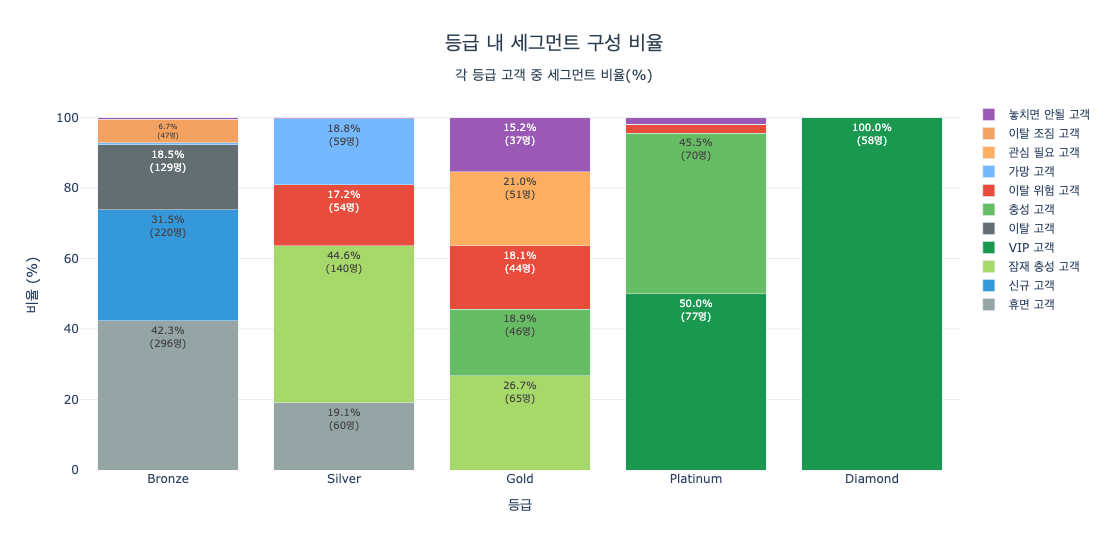

In [24]:
seg_order = seg_dist.sort_values('고객수', ascending=False)['세그먼트'].tolist()
stack_data = cross_pct.reindex(seg_order)
stack_count = cross.reindex(seg_order)

fig = go.Figure()
for seg in seg_order:
    vals = stack_data.loc[seg].fillna(0).values
    counts = stack_count.loc[seg].fillna(0).values.astype(int)
    fig.add_trace(go.Bar(
        x=stack_data.columns.tolist(),
        y=vals,
        name=seg,
        marker_color=seg_color_map.get(seg, '#dfe6e9'),
        text=[f'{v:.1f}%<br>({n}명)' if v >= 5 else '' for v, n in zip(vals, counts)],
        textposition='inside',
        textfont=dict(size=10),
        customdata=[[n] for n in counts],
        hovertemplate=f'<b>{seg}</b><br>%{{y:.1f}}%<br>%{{customdata[0]}}명<extra></extra>'
    ))

fig.update_layout(
    barmode='stack',
    title=dict(
        text='등급 내 세그먼트 구성 비율<br><sub>각 등급 고객 중 세그먼트 비율(%)</sub>',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    xaxis=dict(title='등급'),
    yaxis=dict(title='비율 (%)', gridcolor='#ececec', range=[0, 105]),
    plot_bgcolor='white',
    height=550,
    legend=dict(orientation='v', x=1.01, y=1)
)
fig.show()

---
## 등급별 분석

In [25]:
grade_order = ['Bronze', 'Silver', 'Gold', 'Platinum', 'Diamond']
color_map = {
    'Bronze': '#CD7F32',
    'Silver': '#C0C0C0',
    'Gold': '#FFD700',
    'Platinum': '#E0B0FF',
    'Diamond': '#B9F2FF'
}

grade_analysis = pd.DataFrame({
    '고객수': rfm['등급'].value_counts(),
    '고객비중(%)': rfm['등급'].value_counts(normalize=True) * 100,
    '매출합계': rfm.groupby('등급')['Monetary'].sum(),
    '매출비중(%)': rfm.groupby('등급')['Monetary'].sum() / rfm['Monetary'].sum() * 100,
    '1인당지출': rfm.groupby('등급')['Monetary'].mean()
}).round(2)

grade_analysis = grade_analysis.reindex(grade_order)
grade_analysis

,고객수,고객비중(%),매출합계,매출비중(%),1인당지출
등급,,,,,
Bronze,699,47.62,529658.14,10.98,757.74
Silver,314,21.39,777400.90,16.12,2475.80
Gold,243,16.55,1174042.35,24.34,4831.45
Platinum,154,10.49,1330173.42,27.58,8637.49
Diamond,58,3.95,1011350.49,20.97,17437.08


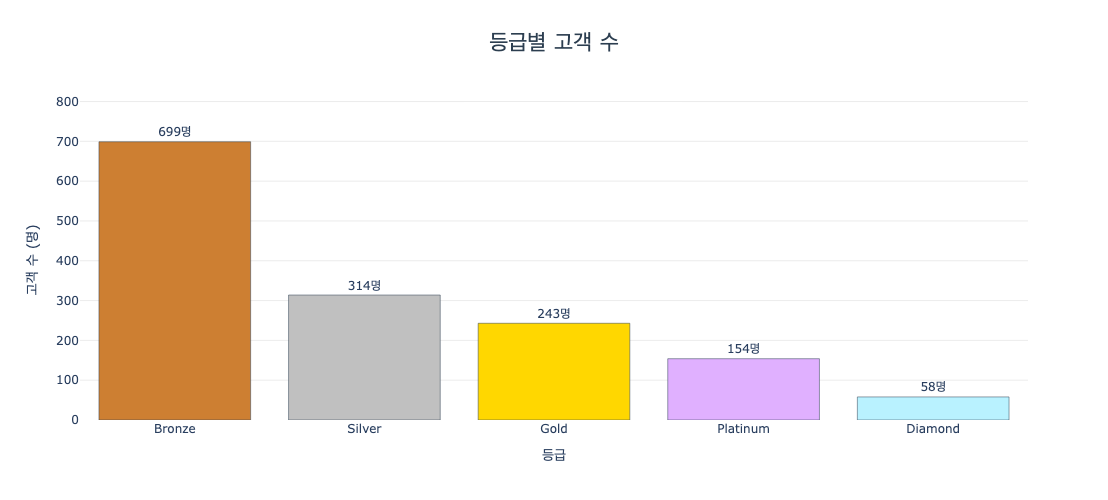

In [26]:
fig = go.Figure(go.Bar(
    x=grade_analysis.index,
    y=grade_analysis['고객수'],
    marker=dict(
        color=[color_map[g] for g in grade_analysis.index],
        line=dict(color='#2c3e50', width=0.5)
    ),
    text=grade_analysis['고객수'].apply(lambda x: f'{x:,}명'),
    textposition='outside'
))

fig.update_layout(
    title=dict(text='등급별 고객 수',
               font=dict(size=22, color='#2c3e50'), x=0.5, xanchor='center'),
    height=500, plot_bgcolor='white',
    yaxis=dict(range=[0, grade_analysis['고객수'].max() * 1.15], gridcolor='#ececec'),
    xaxis_title='등급', yaxis_title='고객 수 (명)'
)
fig.show()

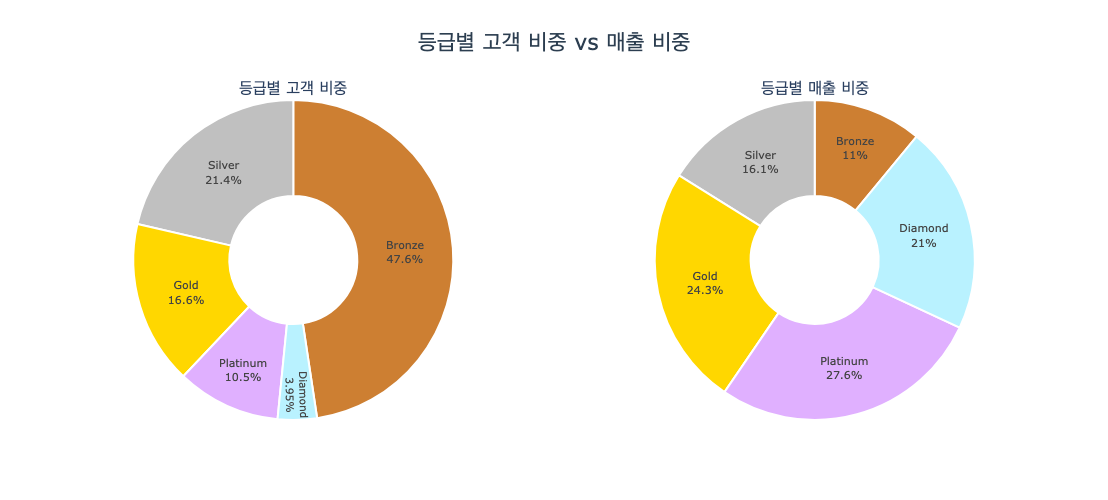

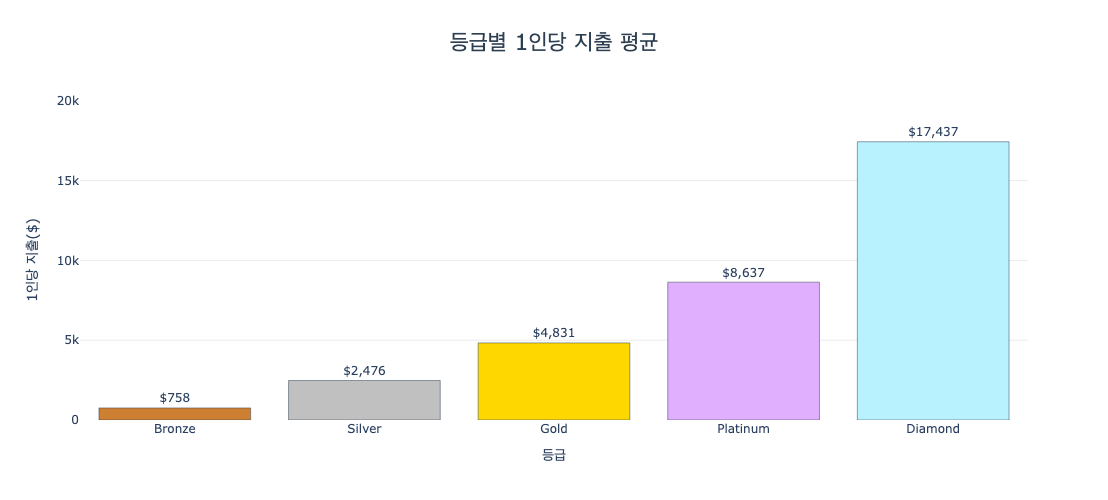

In [27]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['등급별 고객 비중', '등급별 매출 비중'],
    specs=[[{'type': 'pie'}, {'type': 'pie'}]]
)

for col, value_col in enumerate(['고객비중(%)', '매출비중(%)'], 1):
    fig.add_trace(
        go.Pie(
            labels=grade_analysis.index,
            values=grade_analysis[value_col],
            marker=dict(
                colors=[color_map[g] for g in grade_analysis.index],
                line=dict(color='white', width=2)
            ),
            textinfo='label+percent', textposition='inside',
            textfont=dict(size=11), showlegend=False, hole=0.4, sort=False
        ),
        row=1, col=col
    )

fig.update_layout(
    title=dict(text='등급별 고객 비중 vs 매출 비중',
               font=dict(size=22, color='#2c3e50'), x=0.5, xanchor='center'),
    height=500, plot_bgcolor='white'
)
fig.show()

fig2 = go.Figure(go.Bar(
    x=grade_analysis.index,
    y=grade_analysis['1인당지출'],
    marker=dict(
        color=[color_map[g] for g in grade_analysis.index],
        line=dict(color='#2c3e50', width=0.5)
    ),
    text=grade_analysis['1인당지출'].apply(lambda x: f'${x:,.0f}'),
    textposition='outside'
))
fig2.update_layout(
    title=dict(text='등급별 1인당 지출 평균',
               font=dict(size=22, color='#2c3e50'), x=0.5, xanchor='center'),
    height=500, plot_bgcolor='white',
    yaxis=dict(range=[0, grade_analysis['1인당지출'].max() * 1.15], gridcolor='#ececec'),
    xaxis_title='등급', yaxis_title='1인당 지출($)'
)
fig2.show()

In [28]:
visit_days = (
    df.groupby('고객ID')['거래날짜']
    .nunique()
    .reset_index()
    .rename(columns={'거래날짜': '방문일수'})
)
visit_days = visit_days.merge(rfm[['고객ID', '등급']], on='고객ID')
visit_days['재방문횟수'] = visit_days['방문일수'] - 1
visit_days['재방문횟수'].describe()

count    1468.000000
mean        1.184605
std         2.233929
min         0.000000
25%         0.000000
50%         0.500000
75%         2.000000
max        33.000000
Name: 재방문횟수, dtype: float64

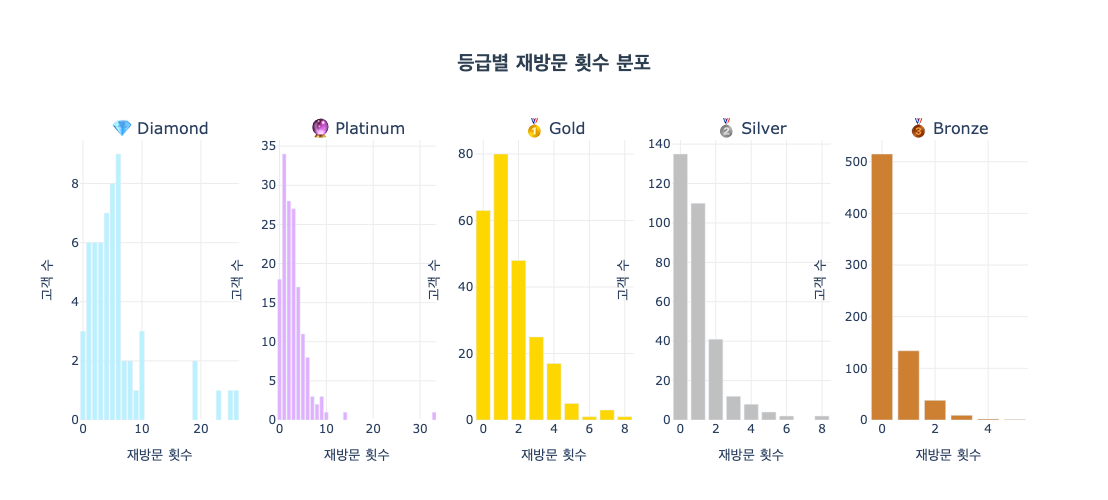

In [29]:
grades_display = ['Diamond', 'Platinum', 'Gold', 'Silver', 'Bronze']
grade_colors_list = ['#B9F2FF', '#E0B0FF', '#FFD700', '#C0C0C0', '#CD7F32']

fig = make_subplots(
    rows=1, cols=5,
    subplot_titles=['💎 Diamond', '🔮 Platinum', '🥇 Gold', '🥈 Silver', '🥉 Bronze']
)

for i, (grade, color) in enumerate(zip(grades_display, grade_colors_list), 1):
    data = (
        visit_days[visit_days['등급'] == grade]['재방문횟수']
        .value_counts()
        .sort_index()
    )
    fig.add_trace(
        go.Bar(x=data.index, y=data.values,
               marker_color=color, showlegend=False, name=grade),
        row=1, col=i
    )

fig.update_layout(
    title=dict(
        text='<b>등급별 재방문 횟수 분포<b>',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    height=500, margin=dict(t=140), plot_bgcolor='white'
)
fig.update_xaxes(title_text='재방문 횟수', gridcolor='#ececec')
fig.update_yaxes(title_text='고객 수', gridcolor='#ececec')
fig.show()

In [30]:
print('등급별 재방문율 (다른 날 재방문한 고객 비율)')
for grade in grade_order:
    data = visit_days[visit_days['등급'] == grade]['재방문횟수']
    revisit = (data >= 1).sum()
    total = len(data)
    print(f'  {grade:8s}: {revisit/total*100:.1f}% ({revisit}/{total})')

등급별 재방문율 (다른 날 재방문한 고객 비율)
  Bronze  : 26.3% (184/699)
  Silver  : 57.0% (179/314)
  Gold    : 74.1% (180/243)
  Platinum: 88.3% (136/154)
  Diamond : 94.8% (55/58)


In [31]:
revisit_rate = (
    visit_days.groupby('등급')
    .agg(
        재방문고객=('재방문횟수', lambda x: (x >= 1).sum()),
        전체고객=('재방문횟수', 'count')
    )
    .assign(재방문율=lambda x: (x['재방문고객'] / x['전체고객'] * 100).round(1))
    .reindex(grade_order)
    .reset_index()
)
revisit_rate

,등급,재방문고객,전체고객,재방문율
0,Bronze,184,699,26.3
1,Silver,179,314,57.0
2,Gold,180,243,74.1
3,Platinum,136,154,88.3
4,Diamond,55,58,94.8


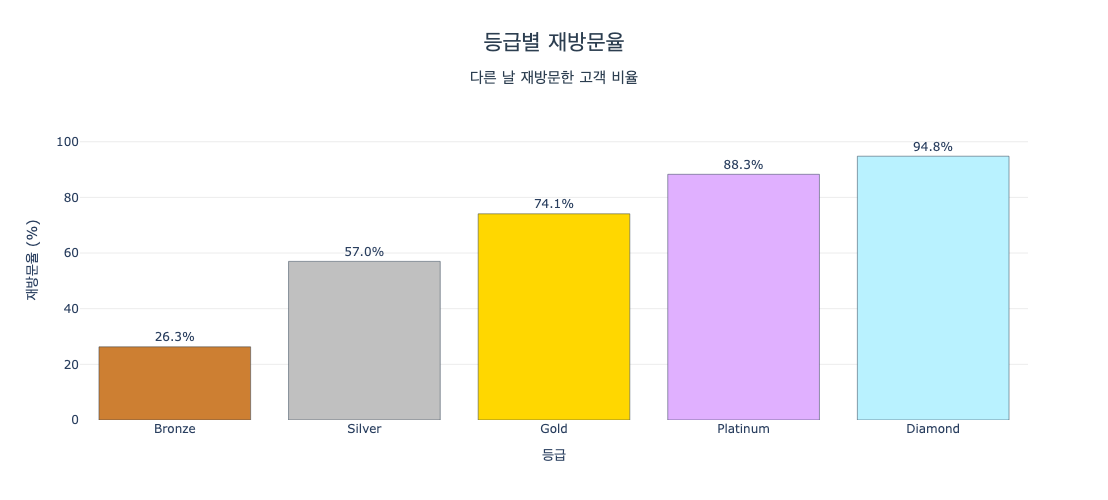

In [32]:
fig = go.Figure(go.Bar(
    x=revisit_rate['등급'],
    y=revisit_rate['재방문율'],
    marker=dict(
        color=[color_map[g] for g in revisit_rate['등급']],
        line=dict(color='#2c3e50', width=0.5)
    ),
    text=revisit_rate.apply(lambda row: f"{row['재방문율']:.1f}%", axis=1),
    textposition='outside'
))

fig.update_layout(
    title=dict(
        text='등급별 재방문율<br><sub>다른 날 재방문한 고객 비율</sub>',
        font=dict(size=22, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    height=500, plot_bgcolor='white',
    yaxis=dict(range=[0, 115], gridcolor='#ececec', title='재방문율 (%)'),
    xaxis_title='등급'
)
fig.show()

---
## 분석 결과 DB 적재

등급별 세부 분석에서 바로 활용할 수 있도록 RFM 산출 결과 전체를 `rfm_result` 테이블에 저장한다.  
이후 분석 노트북은 `orders_master` JOIN 없이 `rfm_result`만 쿼리하면 된다.

| 컬럼 | 설명 |
|------|------|
| 고객ID | 고객 식별자 |
| 등급 | Bronze / Silver / Gold / Platinum / Diamond |
| 세그먼트 | VIP 고객 / 충성 고객 / 잠재 충성 고객 등 11개 행동 기반 세그먼트 |
| R / F / M | RFM 점수 (각 1-5) |
| RFM_score | R + F + M 합산 점수 |
| Recency | 마지막 구매 후 경과일 |
| Frequency | 거래 횟수 |
| Monetary | 누적 구매금액 |

In [33]:
rfm_save = rfm[['고객ID', '등급', 'Segment', 'R', 'F', 'M', 'RFM_score', 'Recency', 'Frequency', 'Monetary']].rename(columns={'Segment': '세그먼트'})
rfm_save.to_sql(
    name='rfm_result',
    con=engine,
    if_exists='replace',
    index=False
)
print(f'저장 완료: {len(rfm_save):,}행')

저장 완료: 1,468행


In [34]:
with engine.connect() as conn:
    count = conn.execute(text('SELECT COUNT(*) FROM rfm_result')).scalar()
print(f'적재 확인: {count:,}행')

적재 확인: 1,468행


---
## 고객 등급별 분석 결과

**💎 Diamond (고충성 고가치 고객군)**

고객 비중은 3.95%(58명)으로 가장 적지만 1인당 지출이 `$17,437`로 압도적으로 높으며, 전체 매출의 20.97%를 담당한다.  
재방문율 94.8%로 거의 전원이 다른 날 재방문한 이력이 있는 핵심 충성 고객군이다.  
세그먼트 구성: **VIP 고객 100%** — 해당 등급 전원이 최근·고빈도·고금액 구매 패턴에 해당한다.

---

**🔮 Platinum (고가치 안정 구매 고객군, 단일 등급 최대 매출)**

고객 비중 10.49%(154명)이며 매출 기여 27.58%로 단일 등급 중 가장 높다.  
1인당 지출 `$8,637`은 Diamond의 약 50% 수준이며, 재방문율 88.3%로 구매 지속성이 높다.  
세그먼트 구성: VIP(50.0%) + 충성(45.5%) = 95.5%가 안정적 충성 패턴. 이탈 위험(2.6%) + 놓치면 안될(1.9%) 합산 4.5%는 소수이지만 과거 고가치 이력을 가진 고객이다.

---

**🥇 Gold (충성 중간층)**

고객 비중 16.55%(243명)으로 단일 등급 중 두 번째로 높은 매출 기여(24.34%)를 차지한다.  
1인당 지출 `$4,831`에 재방문율 74.1%로 구매 의지가 확인된 핵심 중간층이나, 상위 등급 대비 재방문율 격차가 뚜렷하다.  
세그먼트 구성: 충성(18.9%) + 잠재 충성(26.7%) = 45.6%가 성장 가능 세그먼트이나, 관심 필요(21.0%) + 이탈 위험(18.1%) + 놓치면 안될(15.2%) = 54.3%가 이탈 위험군으로 과반을 차지하고 있다.

---

**🥈 Silver (잠재 성장 고객군)**

Gold와 유사한 고객 수(314명, 21.39%)이지만 1인당 지출 `$2,476`으로 Gold의 절반 수준이다.  
재방문율 57.0%로 절반 가까이가 단 하루만 구매하고 이탈한 상태다.  
세그먼트 구성: 잠재 충성(44.6%) + 가망(18.8%) = 63.4%가 성장 가능 세그먼트로 전환 잠재력이 존재하나, 휴면(19.1%) + 이탈 위험(17.2%) = 36.3%가 재참여 없이 이탈 조짐을 보이고 있다.

---

**🥉 Bronze (이탈 위험 고객군)**

전체 고객의 47.62%(699명)로 가장 많지만 매출 기여는 10.98%에 그친다.  
재방문율 26.3%로 4명 중 3명이 단 하루만 구매하고 재방문하지 않아 이탈 위험이 가장 높은 등급이다.  
세그먼트 구성: 휴면(42.3%) + 이탈(18.5%) + 이탈 조짐(6.7%) = 67.5%가 이탈 관련 세그먼트. 신규 고객(31.5%)은 첫 구매 후 재방문 없이 Bronze에 머문 상태로, 초기 이탈이 이 등급의 낮은 재방문율을 주도하고 있다.

---

## 다음 분석 방향

재방문율과 1인당 지출 두 축을 기준으로 4개 그룹으로 나누어 세부 분석을 진행한다.

Diamond·Platinum은 재방문율 88% 이상에 1인당 지출 `$8K` 이상으로 충성 구매 패턴이 이미 형성된 고가치 고객군이다.  
Gold는 단일 등급 두 번째 매출(24.34%)을 담당하면서도 재방문율(74.1%)이 상위 두 등급 대비 14-21%p 낮아, 재방문 주기와 지출 패턴을 집중 분석할 필요가 있다.  
Silver는 재방문율 57.0%로 전환 잠재력이 있는 안정군(63.4%)과 이탈군(36.3%)이 공존하며, Gold 전환과 안정군 성장이 핵심 과제다.  
Bronze는 전체 고객의 47.62%를 차지하나 재방문율 26.3%로 가장 낮아, 재활성화와 첫 구매 유지가 핵심 과제다.

| 분석 그룹 | 고객 비중 | 매출 비중 | 재방문율 | 핵심 질문 |
|----------|:-------:|:-------:|:-------:|---------|
| 💎 Diamond + 🔮 Platinum | 14.4% (212명) | 48.6% | 88-95% | 언제, 어떤 패턴으로 재구매하는가? |
| 🥇 Gold | 16.6% (243명) | 24.3% | 74.1% | 왜 상위 등급보다 재방문이 적은가? |
| 🥈 Silver | 21.4% (314명) | 16.1% | 57.0% | Gold 전환 + 안정군 성장 |
| 🥉 Bronze | 47.6% (699명) | 11.0% | 26.3% | 재활성화 + 첫 구매 유지 |

---

## 각 등급을 독립 노트북으로 분석하는 이유

Diamond·Platinum은 재방문율 88-95%로 세그먼트 구성이 유사해(VIP 100% / VIP+충성 95.5%) 함께 분석한다.  
Gold·Silver·Bronze는 인접 등급이라도 재방문율·세그먼트 구성·분석 목적이 단계마다 달라 각각 독립 분석한다.

| 구분 | Gold (65-80점) | Silver (50-65점) | Bronze (20-50점) |
|------|:------------:|:--------------:|:--------------:|
| 고객 비중 | 16.6% (243명) | 21.4% (314명) | 47.6% (699명) |
| 매출 비중 | 24.3% | 16.1% | 11.0% |
| 재방문율 | 74.1% | 57.0% | 26.3% |
| 1인당 지출 | `$4,831` | `$2,476` | `$758` |
| 주도 세그먼트 | 충성·잠재충성 (45.6%) | 잠재충성·가망 (63.4%) | 휴면·신규 (73.8%) |
| 핵심 질문 | Platinum 전환 + 이탈 방어 | Gold 전환 + 안정군 성장 | 재활성화 + 첫 구매 유지 |

- Gold와 Silver는 재방문율 17%p 차이, 1인당 지출 약 2배 차이 — 세그먼트 구조도 Gold는 이탈 위험군 다수(54.3%), Silver는 안정 성장군 다수(63.4%)로 반전
- Silver와 Bronze는 재방문율 31%p 차이, 분석 목적 자체가 달라 묶을 이유가 없음